In [1]:
##### extra module
import csv
import random
import math
from collections import defaultdict, Counter
import statistics
import matplotlib.pyplot as plt


In [2]:
school_penalty = 50
gender_penalty = 35
cgpa_penalty = 70

In [3]:
#retriving students data
def retrieve_data(file):
    students_data = []
    with open(file, "r" , newline='') as f:
        key = csv.DictReader(f)             #use the data from the first row as keys for the dictionary in subsequent lines
        for i in key:                       # should treat each row as dictionary
            temp = {j:k for j,k in i.items()}
            try:
                temp['CGPA'] = float(temp['CGPA'])
            except:
                temp['CGPA'] = 0.0    #No records then 0
            students_data.append(temp)
    return students_data

#debugging
#print(retrieve_data("records.csv"))

In [4]:
#uploading students data to a csv file with the assigned team
def write_teams(file, filepath):
    with open(filepath, 'w', newline = '') as f:
        writer = csv.DictWriter(f, fieldnames=["Tutorial Group", "Student ID", "School", "Name", "Gender", "CGPA", "Team Assigned"])

        writer.writeheader()

        for r in file:
            out = {k: r.get(k, "") for k in ["Tutorial Group", "Student ID", "School", "Name", "Gender", "CGPA", "Team Assigned"]}
            writer.writerow(out)

In [5]:
def gpa_quartile(grade : list):
    sorted_vals = sorted(grade)
    n = len(sorted_vals)                               #50
    
    def percentile(p : float):
        return max(0, min(n-1, int(math.floor(p * n))))
        
    q1 = sorted_vals[percentile(0.25)]
    q2 = sorted_vals[percentile(0.5)]
    q3 = sorted_vals[percentile(0.75)]
    
    def label(x):
        if x <= q1:
            return 0
        elif x <= q2:
            return 1
        elif x <= q3:
            return 2
        else:
            return 3
    return label


In [6]:
def mean_std(values):
    if len(values) == 0:
        return 0.0, 0.0
    if len(values) == 1:
        return values[0], 0.0
    aver = sum(values) / len(values)
    var = sum((v - aver) ** 2 for v in values) / len(values)
    return aver, math.sqrt(var)

In [7]:
def initial_assignment(students : list, sizes : list):

    cgpas = [s['CGPA'] for s in students]           # find all cgpas value and find the quartile value
    cgpa_value = gpa_quartile(cgpas)

    # group students by (school, gender, q value)
    buckets = defaultdict(list)                       #divide to each bucket
                                                      #each buckets contain students of same school, same gender and same gpa quartile
    for s in students:
        key = (s['School'], s['Gender'], cgpa_value(s['CGPA']))
        buckets[key].append(s)

    # sort so that large buckets go first --> ensure the large buckets are used first
    keys_sorted = sorted(buckets.keys(), key=lambda k: len(buckets[k]), reverse=True)
    
    #10 empty teams
    teams = [[] for i in sizes]
    caps = sizes[:]                               # a copy of teams that later can be modified
    
    # round-robin assignment from each bucket
    for key in keys_sorted:
        bucket = buckets[key]
        school, gender, _q = key
        while bucket:
            # Find all teams index that still have space (caps[i] > 0)
            remaining_teams_indexes = [i for i, c in enumerate(caps) if c > 0]       #both value and index
            
            #Find the best team for students in each bucket
            def score(i):
                team = teams[i]
                count_school = sum(1 for m in team if m['School'] == school)        # +1 if a member in this team has the same school as bucket
                count_gender = sum(1 for m in team if m['Gender'] == gender)        # +1 if same gender
                return (count_school, count_gender, -caps[i])                         # if they are the same, choose the team with lower capacity. Hence, -caps[i]

            
            best = min(remaining_teams_indexes, key=score)                          #key=score means compare cnt_score first, then cnt_gender, then -caps[i]
            #add the suitable student
            student_chosen = bucket.pop()
            teams[best].append(student_chosen)
            #reduce that team’s capacity by 1
            caps[best] -= 1
    return teams
    

In [8]:
def team_penalty(team, group_mean, group_std):
    #see how many students are in this team; if the team is empty (edge case), no penalty.
    n = len(team)
    if n == 0:
        return 0.0
        
    # school majority

    sch_count = Counter([m['School'] for m in team])        #build a dictionary of how many times each school appears in the team
    top_school_count = max(sch_count.values())               #give the largest number of student from the same school
    
    majority_school_threshold = 2

    school_pen = 0.0                                         # if too many from the same school (>2), add the school penalty
    if top_school_count > majority_school_threshold:
        school_pen = (top_school_count - majority_school_threshold) * school_penalty

    # gender majority
    majority_gender_threshold = 3                                   # just like school, but the gender should be > 3
    gen_counts = Counter([m['Gender'] for m in team])
    top_gender_count = max(gen_counts.values())
    gender_pen = 0.0
    if top_gender_count > majority_gender_threshold:
        gender_pen = (top_gender_count - majority_gender_threshold) * gender_penalty

    # CGPA deviation penalty.
    cgpas = [m['CGPA'] for m in team]
    team_mean = sum(cgpas) / len(cgpas)              #find average cgpa of a team
    
    if group_std > 0:
        z = abs(team_mean - group_mean) / group_std     #standard deviation and normal distribution
    else:
        z = 0.0
        
    cgpa_pen = z * cgpa_penalty                                   #multiply by gpa penalty

    return school_pen + gender_pen + cgpa_pen

#Now, find the total penalty of all teams
def total_penalty(teams, group_mean, group_std):              
    total = 0
    for t in teams:
        total += team_penalty(t, group_mean, group_std)
    return total


In [9]:
def local_improvement_swaps(teams, group_mean, group_std, max_iters=5000):
    current_pen = total_penalty(teams, group_mean, group_std) 
    iters = 0
    no_improve_count = 0
    
    while iters < max_iters and no_improve_count < 1000:                 #if swap 1000 times without improvement, break
        iters += 1
        
        #Randomly pick two different teams.
        i, j = random.sample(range(len(teams)), 2)                  #pick 2 random teams with different indexes
     
        a = random.randrange(len(teams[i]))
        b = random.randrange(len(teams[j])) #Randomly choose one student index from team i and one from team j, to be swapped
        
        #Find penalty of 2 teams before swap
        before = team_penalty(teams[i], group_mean, group_std) + team_penalty(teams[j], group_mean, group_std)
        
        teams[i][a], teams[j][b] = teams[j][b], teams[i][a]
        
        #Find penalty of 2 teams after swqp
        after = team_penalty(teams[i], group_mean, group_std) + team_penalty(teams[j], group_mean, group_std)

        #If improve, keep the swap, else, revert back
        if after < before:
            current_pen += (after - before)
            no_improve_count = 0
        else:
            teams[i][a], teams[j][b] = teams[j][b], teams[i][a]
            no_improve_count += 1 
            #add 1 to the no_improvement_count
    return teams, current_pen

In [10]:
def form_teams_for_tutorial(students : list, team_size = 5, max_swap_iters=5000):
    
    n = len(students)                                   #each tutorial group has 50 students

    sizes = [5 for i in range(10)]           # create 10 teams of 5

    teams = initial_assignment(students, sizes)          #add members to 10 teams
    
    # compute group CGPA stats
    cgpas = [s['CGPA'] for s in students]               #extract all CGPA values for this tutorial group.
    group_mean, group_std = mean_std(cgpas)             #get average CGPA and standard deviation

    #improve by local swap
    teams, final_pen = local_improvement_swaps(teams, group_mean, group_std, max_iters=max_swap_iters)

    #returns a tuple of results for each tutorial group
    return teams, final_pen, group_mean, group_std

In [11]:
all_students = retrieve_data("records.csv") 

# Group by tutorial group
groups = defaultdict(list)
for r in all_students:
    groups[r['Tutorial Group']].append(r)
    
final_records = []                        # each student will include 'Team Assigned'
group_summaries = []                      
total_penalty_all = 0.0

for tg, students in sorted(groups.items()):                                    #sorted() by alphabetical order
    teams, pen, group_mean, group_std = form_teams_for_tutorial(students)
    total_penalty_all += pen                                                   #total penalty
     

    for tidx, team in enumerate(teams, start=1):
        team_id = f"{tg}_T{tidx}"
        for m in team:
            rec = {
                "Tutorial Group": tg,
                "Student ID": m['Student ID'],
                "School": m['School'],
                "Name": m['Name'],
                "Gender": m['Gender'],
                "CGPA": m['CGPA'],
                "Team Assigned": team_id
            }
            final_records.append(rec)
            
    # this part is for summary
    violating = 0
    team_cgpa_means = []
    for team in teams:
        n = len(team)

        #Count the number of group violating the rule of max 2 members of same school per group or max 3 members of same gender per group
        top_school_count = max(Counter([m['School'] for m in team]).values())
        top_gender_count = max(Counter([m['Gender'] for m in team]).values())
        if top_school_count > 2 or top_gender_count > 3:
            violating += 1
                    
        cgpa_mean = sum(m['CGPA'] for m in team) / n
        team_cgpa_means.append(cgpa_mean)

    #This is for summary
    group_summaries.append({
        "Tutorial Group": tg,
        "Students": len(students),
        "Teams": len(teams),
        "Violating Teams": violating,
        "Group Penalty": pen,
        "Avg Team CGPA Mean": (sum(team_cgpa_means)/len(team_cgpa_means)),
        "Group CGPA Mean": group_mean,
        "Group CGPA Std": group_std
    })

# write output CSV with Team Assign column
write_teams(final_records, "teams_output.csv")

print(f"Total penalty across all groups: {total_penalty_all:.2f}")

#Summary
for s in sorted(group_summaries, key=lambda x: x["Tutorial Group"])[:]:
    print(s)


Total penalty across all groups: 1770.09
{'Tutorial Group': 'G-1', 'Students': 50, 'Teams': 10, 'Violating Teams': 0, 'Group Penalty': 5.473619573094259, 'Avg Team CGPA Mean': 4.0956, 'Group CGPA Mean': 4.0956, 'Group CGPA Std': 0.12277068053896256}
{'Tutorial Group': 'G-10', 'Students': 50, 'Teams': 10, 'Violating Teams': 0, 'Group Penalty': 9.174166160748616, 'Avg Team CGPA Mean': 4.118, 'Group CGPA Mean': 4.118, 'Group CGPA Std': 0.1220819396962548}
{'Tutorial Group': 'G-100', 'Students': 50, 'Teams': 10, 'Violating Teams': 0, 'Group Penalty': 4.5704327217637735, 'Avg Team CGPA Mean': 4.094199999999999, 'Group CGPA Mean': 4.0942, 'Group CGPA Std': 0.11027402232620336}
{'Tutorial Group': 'G-101', 'Students': 50, 'Teams': 10, 'Violating Teams': 0, 'Group Penalty': 4.438227563241526e-12, 'Avg Team CGPA Mean': 4.108, 'Group CGPA Mean': 4.1080000000000005, 'Group CGPA Std': 0.1397712416772492}
{'Tutorial Group': 'G-102', 'Students': 50, 'Teams': 10, 'Violating Teams': 0, 'Group Penalty':

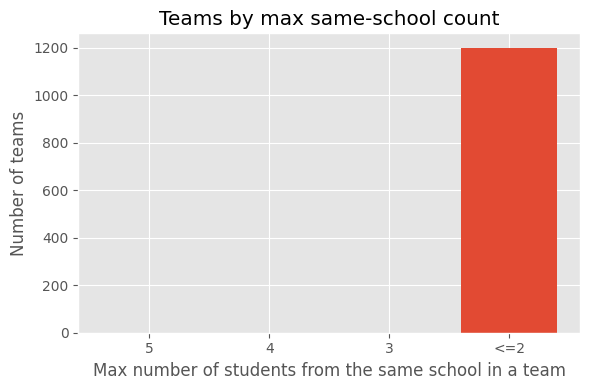

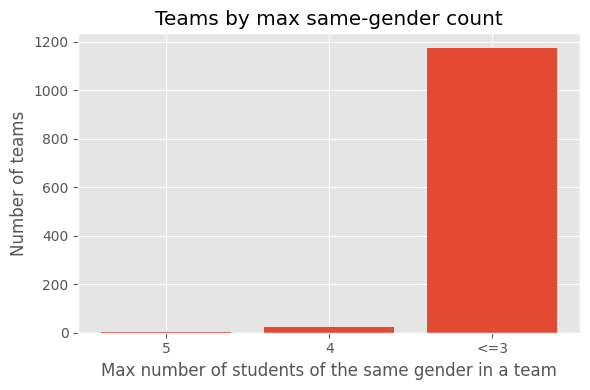

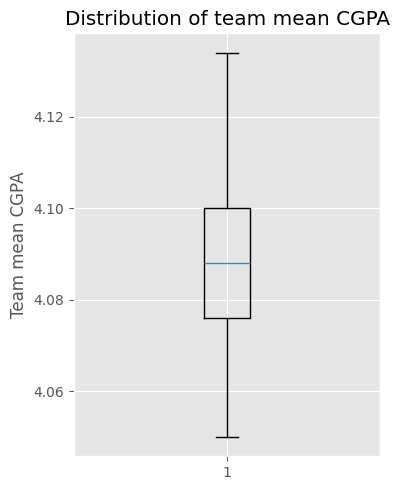

In [12]:
teams = defaultdict(list)
for rec in final_records:
    teams[rec["Team Assigned"]].append(rec)

same_school_hist = Counter()    # for 5, 4, 3, <=2 same school
same_gender_hist = Counter()   # for 5, 4, <=3 same gender
team_cgpa_means = []           # for CGPA boxplot

for team_id, members in teams.items():
    schools = [m["School"] for m in members]
    genders = [m["Gender"] for m in members]
    cgpas   = [m["CGPA"] for m in members]

    school_counts = Counter(schools)
    gender_counts = Counter(genders)

    max_same_school = max(school_counts.values())
    max_same_gender = max(gender_counts.values())

    #School categories: 5, 4, 3, <=2
    if max_same_school >= 5:
        same_school_hist["5"] += 1
    elif max_same_school == 4:
        same_school_hist["4"] += 1
    elif max_same_school == 3:
        same_school_hist["3"] += 1
    else:
        same_school_hist["<=2"] += 1

    #Gender categories: 5, 4, <=3
    if max_same_gender >= 5:
        same_gender_hist["5"] += 1
    elif max_same_gender == 4:
        same_gender_hist["4"] += 1
    else:
        same_gender_hist["<=3"] += 1

    #Team mean CGPA
    team_cgpa_means.append(sum(cgpas) / len(cgpas))

school_cats = ["5", "4", "3", "<=2"]
gender_cats = ["5", "4", "<=3"]

school_counts = [same_school_hist[c] for c in school_cats]
gender_counts = [same_gender_hist[c] for c in gender_cats]

plt.style.use("ggplot")

#Graph 1: School diversity
plt.figure(figsize=(6, 4))
plt.bar(range(len(school_cats)), school_counts)
plt.xticks(range(len(school_cats)), school_cats)
plt.xlabel("Max number of students from the same school in a team")
plt.ylabel("Number of teams")
plt.title("Teams by max same-school count")
plt.tight_layout()
plt.show()

#Graph 2: Gender diversity
plt.figure(figsize=(6, 4))
plt.bar(range(len(gender_cats)), gender_counts)
plt.xticks(range(len(gender_cats)), gender_cats)
plt.xlabel("Max number of students of the same gender in a team")
plt.ylabel("Number of teams")
plt.title("Teams by max same-gender count")
plt.tight_layout()
plt.show()

#Graph 3: CGPA (team mean)
plt.figure(figsize=(4, 5))
plt.boxplot(team_cgpa_means, vert=True)
plt.ylabel("Team mean CGPA")
plt.title("Distribution of team mean CGPA")
plt.tight_layout()
plt.show()
